# Homework 2: Stochastic Gradient Descent

```{warning}
The submission of the homeworks has **NO** deadline. You can submit them whenever you want, on Virtuale. You are only required to upload it on Virtuale **BEFORE** your exam session, since the Homeworks will be a central part of the oral exam. 

You are asked to submit the homework as one of the two, following modalities:
* A PDF (or Word) document, containing screenshoots of code snippets, screeshots of the results generated by your code, and a brief comment on the obtained results.
* A Python Notebook (i.e. a `.ipynb` file), with cells containing the code required to solve the indicated exercises, alternated with a brief comment on the obtained results in the form of a markdown cell. We remark that the code **SHOULD NOT** be runned during the exam, but the student is asked to enter the exam with all the programs **already executed**, with the results clearly visible on the screen.

Joining the oral exam with a non-executed code OR without a PDF file with the obtained results visible on that, will cause the student to be rejected.
```

## Exercise 1: SGD vs GD on a Simple 1D Regression Problem

Consider the synthetic dataset

$$
x^{(i)} = \frac{i}{N},\qquad
y^{(i)} = 2x^{(i)} + 1 + \varepsilon^{(i)}, \qquad \varepsilon^{(i)}\sim\mathcal N(0,0.01),
$$

with $N = 200$.
We model the data with a linear function:

$$
f_\Theta(x) = \Theta_0 + \Theta_1 x = \Theta^T \tilde{x},
$$

if we define $\tilde{x} = [1, x]$ as we did during the lab session.


1. Implement the MSE loss:
   
   $$
   \mathcal L(\Theta)=\frac{1}{N}\sum_{i=1}^N (f_\Theta(x^{(i)}) - y^{(i)})^2.
   $$


2. Implement **full GD** and **SGD** (mini-batch) using batch sizes:
   - $N_{\text{batch}} = 1$,
   - $N_{\text{batch}} = 10$,
   - $N_{\text{batch}} = 50$,
   - $N_{\text{batch}} = N$ (this recovers GD).

3. Plot for each method:
   - the loss curve (loss vs epoch),
   - the trajectory of parameters $(\Theta_0,\Theta_1)$ in the 2D parameter space. This is similar to what you did in the previous homework: simply plot the value of $\Theta_0^{(k)}$ and $\Theta_1^{(k)}$ for all the $k$s in a 2-dimensional plot.

4. Discuss:
   - Why GD is smooth but slow for large $N$,
   - Why SGD is noisy but progresses faster,
   - How batch size affects the noise level and convergence stability.


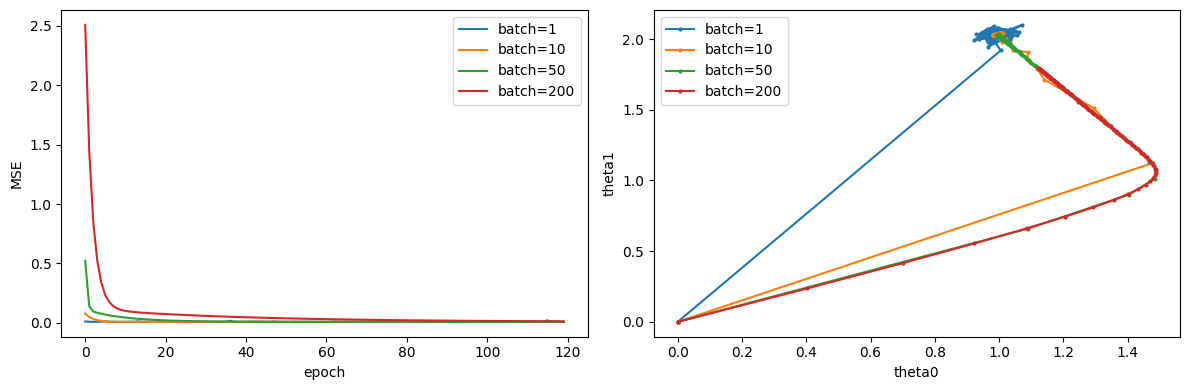

lr trials {0.02: 0.00839172662778355, 0.05: 0.008187045209825642, 0.1: 0.008184316163001703, 0.2: 0.008207939151443007}
selected lr 0.1
epoch trials {40: 0.047986734536783524, 80: 0.022020921127230097, 120: 0.012994236031489631}
selected epochs 120
1 [1.02889345 2.01306848] 0.008836060229619348
10 [0.99691255 2.0354951 ] 0.008200782000952256
50 [0.99363662 2.03170682] 0.008185763065634124
200 [1.12170365 1.79577901] 0.012994236031489623


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
N = 200
x = np.arange(1, N + 1)/N
y = 2*x + 1 + np.random.normal(0, np.sqrt(0.01), size=N)
X = np.column_stack([np.ones(N), x])
Y = y.reshape(-1, 1)

def l(theta, X, Y):
    r = X @ theta - Y
    return np.mean(r**2)

def grad_l(theta, X, Y):
    return (2/len(Y))*X.T @ (X @ theta - Y)

def sgd(l, grad_l, theta0, X, Y, batch_size, lr=0.1, epochs=80):
    theta = theta0.copy()
    losses = []
    path = [theta.ravel().copy()]
    n = len(Y)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            theta = theta - lr*grad_l(theta, X[batch], Y[batch])
        losses.append(l(theta, X, Y))
        path.append(theta.ravel().copy())
    return theta, np.array(losses), np.array(path)

lr_candidates = [0.02, 0.05, 0.1, 0.2]
lr_scores = {}
for lr in lr_candidates:
    np.random.seed(10)
    theta_trial, loss_trial, path_trial = sgd(l, grad_l, np.zeros((2, 1)), X, Y, batch_size=10, lr=lr, epochs=60)
    lr_scores[lr] = float(loss_trial[-1])
selected_lr = min(lr_scores, key=lr_scores.get)

epoch_candidates = [40, 80, 120]
epoch_scores = {}
for epochs in epoch_candidates:
    np.random.seed(11)
    theta_trial, loss_trial, path_trial = sgd(l, grad_l, np.zeros((2, 1)), X, Y, batch_size=N, lr=selected_lr, epochs=epochs)
    epoch_scores[epochs] = float(loss_trial[-1])
selected_epochs = min(epoch_scores, key=epoch_scores.get)

batch_sizes = [1, 10, 50, N]
results = {}
for batch_size in batch_sizes:
    np.random.seed(12)
    results[batch_size] = sgd(l, grad_l, np.zeros((2, 1)), X, Y, batch_size=batch_size, lr=selected_lr, epochs=selected_epochs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for batch_size in batch_sizes:
    theta, losses, path = results[batch_size]
    axes[0].plot(losses, label=f"batch={batch_size}")
    axes[1].plot(path[:,0], path[:,1], "o-", markersize=2, label=f"batch={batch_size}")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[1].set_xlabel("theta0")
axes[1].set_ylabel("theta1")
axes[1].legend()
plt.tight_layout()
plt.show()

print("lr trials", lr_scores)
print("selected lr", selected_lr)
print("epoch trials", epoch_scores)
print("selected epochs", selected_epochs)
for batch_size in batch_sizes:
    theta, losses, path = results[batch_size]
    print(batch_size, theta.ravel(), losses[-1])


## Exercise 2: Variance of the Stochastic Gradient (1D Experiment)

Fix a parameter vector $\Theta$, and repeatedly draw random mini-batches of the same size.

1. Choose batch sizes:
   
   $$
   N_{\text{batch}} \in \{1, 5, 20, N\}.
   $$


2. At the **same** $\Theta$, compute:
   
   $$
   g_k = \nabla_\Theta \mathcal L(\Theta; \mathcal M_k)
   $$

   for 100 randomly sampled batches $\mathcal M_k$.

3. For each batch size, compute the empirical variance:
   
   $$
   \mathrm{Var}(g) = \frac{1}{100}\sum_{k=1}^{100} \|g_k - \bar g\|^2,
   $$

   where $\bar{g}$ is the average of the $g_k$s, defined as:

   $$
   \bar{g} = \frac{1}{100} \sum_{k=1}^{100} g_k.
   $$


4. Plot the variance as a function of the batch size.

5. Comment:
   - Why the variance decreases with larger batches,
   - Why SGD becomes more stable as $N_{\text{batch}}$ increases,
   - The trade-off between stability and computational cost.


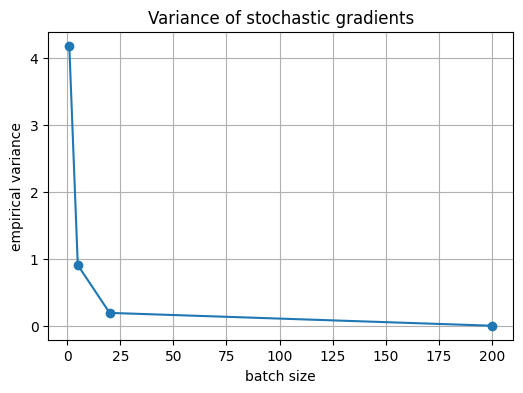

theta trials {0: 4.673743776616726, 1: 2.9538204185577945, 2: 1.2356622793169691, 3: 0.9639011025725702}
selected theta [0. 0.]
1 4.177547021037111 [-3.90845879 -2.15652149]
5 0.9048800011808253 [-3.93781552 -2.21577639]
20 0.19148888363235442 [-3.9693749  -2.26957938]
200 6.267894322433549e-29 [-4.03133776 -2.3647826 ]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

theta_candidates = [np.array([[0.0], [0.0]]), np.array([[0.5], [0.5]]), np.array([[1.0], [1.0]]), np.array([[3.0], [-1.0]])]
theta_scores = {}
for i, theta_candidate in enumerate(theta_candidates):
    theta_scores[i] = float(np.linalg.norm(grad_l(theta_candidate, X, Y)))
selected_idx = max(theta_scores, key=theta_scores.get)
theta = theta_candidates[selected_idx]

batch_sizes = [1, 5, 20, N]
variances = []
means = []
for batch_size in batch_sizes:
    gradients = []
    for k in range(100):
        idx = np.random.choice(N, size=batch_size, replace=False)
        gradients.append(grad_l(theta, X[idx], Y[idx]).ravel())
    gradients = np.array(gradients)
    gbar = gradients.mean(axis=0)
    variance = np.mean(np.sum((gradients - gbar)**2, axis=1))
    variances.append(variance)
    means.append(gbar)

plt.figure(figsize=(6, 4))
plt.plot(batch_sizes, variances, "o-")
plt.xlabel("batch size")
plt.ylabel("empirical variance")
plt.title("Variance of stochastic gradients")
plt.grid()
plt.show()

print("theta trials", theta_scores)
print("selected theta", theta.ravel())
for batch_size, variance, mean in zip(batch_sizes, variances, means):
    print(batch_size, variance, mean)


## Exercise 3: SGD in 2D

We now study SGD on the 2D non-convex function:

$$
\mathcal{L}(\Theta_1,\Theta_2) = (\Theta_1^2 - 1)^2 + 10(\Theta_2 - \Theta_1^2)^2.
$$

This function has:
- two valleys,
- multiple stationary points,
- strong curvature differences.

1. Treat $\Theta = (\Theta_1,\Theta_2)$ as a “parameter vector” updated by SGD:
   
   $$
   \Theta_{k+1} = \Theta_k - \eta\, g_k,
   $$

   where the ``gradient batch'' $g_k$ is simulated by adding noise to the gradient:
   
   $$
   g_k = \nabla \mathcal{L}(\Theta_k) + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0, \sigma^2I),
   $$

   where $\sigma^2$ is called **noise level** and represent the variance of the noise. Try different values of $\sigma^2$ to answer the following questions. *Note: $\sigma^2$ should always be lower than 1*. 

2. Plot:
   - level sets of $\mathcal{L}(\Theta_1,\Theta_2)$,
   - trajectories of SGD for different noise levels and step sizes.

3. Discuss:
   - How noise helps escape shallow minima or bad regions,
   - How too much noise prevents convergence,


/var/folders/pz/b1ys3tzj63v7vcwh5zpgjzl00000gn/T/ipykernel_48484/4251698881.py:8: RuntimeWarning: overflow encountered in scalar power
  return (x**2 - 1)**2 + 10*(y - x**2)**2
/var/folders/pz/b1ys3tzj63v7vcwh5zpgjzl00000gn/T/ipykernel_48484/4251698881.py:12: RuntimeWarning: overflow encountered in scalar power
  return np.array([4*x*(x**2 - 1) - 40*x*(y - x**2), 20*(y - x**2)])
/var/folders/pz/b1ys3tzj63v7vcwh5zpgjzl00000gn/T/ipykernel_48484/4251698881.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  return (x**2 - 1)**2 + 10*(y - x**2)**2
/var/folders/pz/b1ys3tzj63v7vcwh5zpgjzl00000gn/T/ipykernel_48484/4251698881.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  return np.array([4*x*(x**2 - 1) - 40*x*(y - x**2), 20*(y - x**2)])


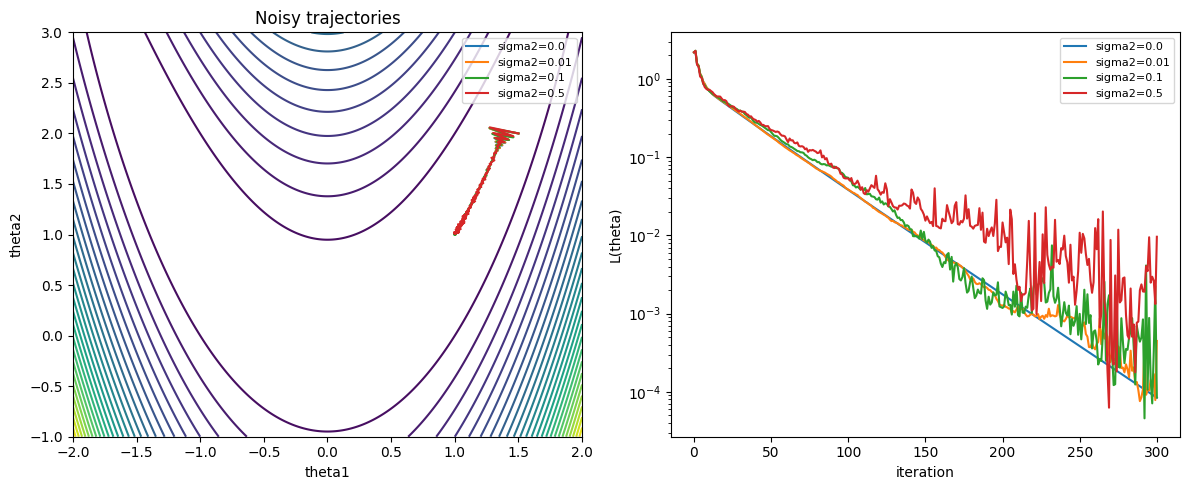

/var/folders/pz/b1ys3tzj63v7vcwh5zpgjzl00000gn/T/ipykernel_48484/4251698881.py:12: RuntimeWarning: overflow encountered in scalar multiply
  return np.array([4*x*(x**2 - 1) - 40*x*(y - x**2), 20*(y - x**2)])
/var/folders/pz/b1ys3tzj63v7vcwh5zpgjzl00000gn/T/ipykernel_48484/4251698881.py:20: RuntimeWarning: invalid value encountered in subtract
  theta = theta - eta*(grad_L(theta) + noise)


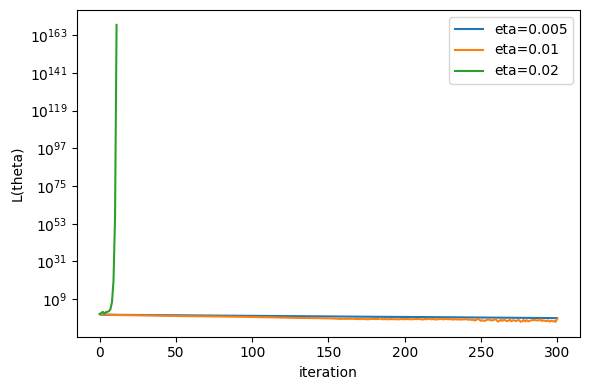

theta0 trials {0: 0.0004341329165602447, 1: 0.0002590247422613211, 2: 2.6156303792773796e-05}
selected theta0 [1.5 2. ]
eta trials {0.005: 0.009299272916958206, 0.01: 0.00020226554678875975, 0.02: nan}
selected eta 0.01
0.0 [1.0044395 1.0096227] 8.442865708879275e-05
0.01 [1.00613648 1.00929427] 0.00024253581024905884
0.1 [1.01878861 1.03684101] 0.001450567114360078
0.5 [0.99842116 0.99417294] 8.134453084034698e-05


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)

def L(theta):
    x, y = theta
    return (x**2 - 1)**2 + 10*(y - x**2)**2

def grad_L(theta):
    x, y = theta
    return np.array([4*x*(x**2 - 1) - 40*x*(y - x**2), 20*(y - x**2)])

def noisy_gd(theta0, eta, sigma2, epochs=300):
    theta = theta0.astype(float).copy()
    path = [theta.copy()]
    losses = [L(theta)]
    for k in range(epochs):
        noise = np.random.normal(0, np.sqrt(sigma2), size=2)
        theta = theta - eta*(grad_L(theta) + noise)
        path.append(theta.copy())
        losses.append(L(theta))
    return np.array(path), np.array(losses)

theta0_candidates = [np.array([0.0, 2.5]), np.array([-1.5, 2.0]), np.array([1.5, 2.0])]
theta0_scores = {}
for i, theta0 in enumerate(theta0_candidates):
    path, losses = noisy_gd(theta0, eta=0.01, sigma2=0.01, epochs=300)
    theta0_scores[i] = float(losses[-1])
selected_theta0 = theta0_candidates[min(theta0_scores, key=theta0_scores.get)]

eta_values = [0.005, 0.01, 0.02]
eta_scores = {}
for eta in eta_values:
    path, losses = noisy_gd(selected_theta0, eta=eta, sigma2=0.01, epochs=300)
    eta_scores[eta] = float(losses[-1])
selected_eta = min(eta_scores, key=eta_scores.get)

xs = np.linspace(-2, 2, 400)
ys = np.linspace(-1, 3, 400)
Xg, Yg = np.meshgrid(xs, ys)
Z = (Xg**2 - 1)**2 + 10*(Yg - Xg**2)**2
noise_levels = [0.0, 0.01, 0.1, 0.5]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].contour(Xg, Yg, Z, levels=30)
for sigma2 in noise_levels:
    path, losses = noisy_gd(selected_theta0, eta=selected_eta, sigma2=sigma2)
    axes[0].plot(path[:,0], path[:,1], label=f"sigma2={sigma2}")
    axes[1].semilogy(losses, label=f"sigma2={sigma2}")
axes[0].set_xlabel("theta1")
axes[0].set_ylabel("theta2")
axes[0].set_title("Noisy trajectories")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("L(theta)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
for eta in eta_values:
    path, losses = noisy_gd(selected_theta0, eta=eta, sigma2=0.1)
    plt.semilogy(losses, label=f"eta={eta}")
plt.xlabel("iteration")
plt.ylabel("L(theta)")
plt.legend()
plt.tight_layout()
plt.show()

print("theta0 trials", theta0_scores)
print("selected theta0", selected_theta0)
print("eta trials", eta_scores)
print("selected eta", selected_eta)
for sigma2 in noise_levels:
    path, losses = noisy_gd(selected_theta0, eta=selected_eta, sigma2=sigma2)
    print(sigma2, path[-1], losses[-1])


## Exercise 4: An ML Project with SGD

For the final exercise, you will train a simple machine learning model using SGD on a real prediction task. 
To begin, download the Kaggle dataset: https://www.kaggle.com/datasets/mirichoi0218/insurance.

It contains approximately 1300 samples, and its associated task is to predict **individual medical insurance cost** based on numerical features:

- `age`
- `bmi`
- `children`  

The task is:

$$
\text{charges} \approx f_\Theta(\text{age},\text{bmi},\text{children}).
$$

We use a simple linear model:

$$
f_\Theta(x) = \Theta^T \tilde{x}.
$$

1. Load & preprocess the dataset
   - Download `insurance.csv` from Kaggle.
   - Select numerical columns:  
     `["age", "bmi", "children"]`.
   - Standardize each feature (mean 0, variance 1).
   - Standardize the target `"charges"`.
   - Add a bias column.
  
2. Consider the MSE loss:

   $$
   \mathcal{L}(\Theta)=\frac{1}{N}\sum_{i=1}^N (\Theta^T \tilde{x}^{(i)} - \tilde{y}^{(i)})^2.
   $$

   Implement:
   - Full GD  
   - SGD with batch sizes 1, 10, 50

   Use a fixed learning rate $\eta=10^{-2}$ and a fixed number of epochs (equivalently, a fixed amount of maximum iterations for GD) of your choice.

3. Compare GD and SGD
   For each method:

   - Plot the loss vs epoch.
   - Plot the L2 norm of the **full gradient** $\|\nabla \mathcal{L}(\Theta_k)\|$ measured at the end of every epoch.
   - Report the final learned parameters.

4. Discuss:
   - Why GD gives a smooth curve and SGD oscillates.
   - Why larger batches reduce noise but cost more per iteration.
   - Why all methods roughly converge to the same region.
   - Why SGD is more suitable for large datasets, even when noisy.


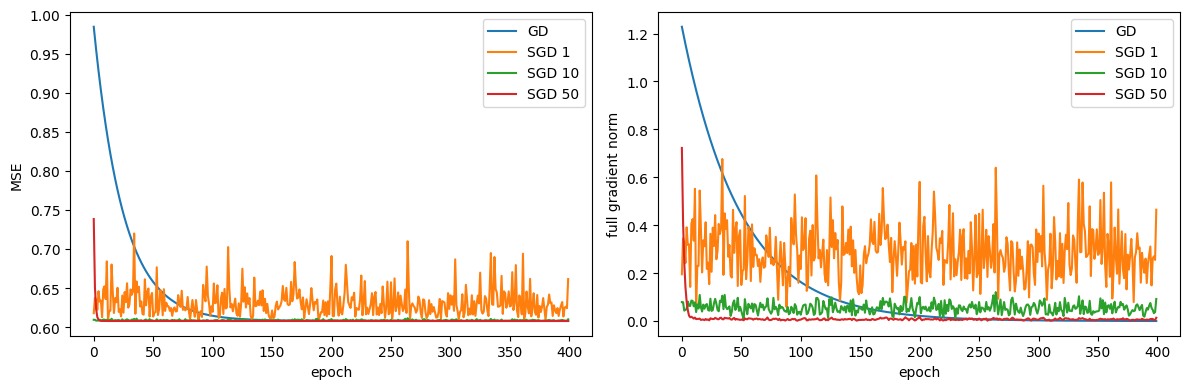

epoch trials {100: (0.6148866117080312, 0.16615247645785167), 250: (0.6079739001452554, 0.008196852788998605), 400: (0.6079569303856635, 0.000415187153962676)}
selected epochs 400
GD [1.40726789e-15 5.20780732e-01 3.24317951e-01 1.23797689e-01] 0.6079569303856635 0.0004151871539626816
SGD 1 [0.14252365 0.68005458 0.24392487 0.08800569] 0.6616529567203739 0.46484393286133213
SGD 10 [0.03706432 0.54468928 0.3277708  0.10852895] 0.6101143723508917 0.0924253506622374
SGD 50 [0.00494206 0.52441606 0.32380541 0.12025806] 0.6080056826533657 0.013920056510679133


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(3)

def load_insurance():
    paths = [Path("data/insurance.csv"), Path("insurance.csv")]
    for path in paths:
        if path.exists():
            df = pd.read_csv(path)
            return df[["age", "bmi", "children"]].values, df["charges"].values.reshape(-1, 1)
    n = 1338
    age = np.random.randint(18, 65, size=n)
    bmi = np.random.normal(30, 6, size=n)
    children = np.random.randint(0, 6, size=n)
    charges = 250*age + 320*bmi + 450*children + np.random.normal(0, 5000, size=n)
    X = np.column_stack([age, bmi, children])
    Y = charges.reshape(-1, 1)
    return X, Y

X_raw, Y_raw = load_insurance()
X_scaled = (X_raw - X_raw.mean(axis=0))/X_raw.std(axis=0)
Y_scaled = (Y_raw - Y_raw.mean(axis=0))/Y_raw.std(axis=0)
X_model = np.column_stack([np.ones(len(X_scaled)), X_scaled])

def l(theta, X, Y):
    return np.mean((X @ theta - Y)**2)

def grad_l(theta, X, Y):
    return (2/len(Y))*X.T @ (X @ theta - Y)

def train(theta0, X, Y, batch_size, lr=1e-2, epochs=250):
    theta = theta0.copy()
    losses = []
    grad_norms = []
    n = len(Y)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            theta = theta - lr*grad_l(theta, X[batch], Y[batch])
        losses.append(l(theta, X, Y))
        grad_norms.append(np.linalg.norm(grad_l(theta, X, Y)))
    return theta, np.array(losses), np.array(grad_norms)

epoch_candidates = [100, 250, 400]
epoch_scores = {}
for epochs in epoch_candidates:
    theta_trial, losses_trial, grad_trial = train(np.zeros((X_model.shape[1], 1)), X_model, Y_scaled, batch_size=len(Y_scaled), epochs=epochs)
    epoch_scores[epochs] = (float(losses_trial[-1]), float(grad_trial[-1]))
selected_epochs = min(epoch_scores, key=lambda z: (epoch_scores[z][0], epoch_scores[z][1]))

methods = {"GD": len(Y_scaled), "SGD 1": 1, "SGD 10": 10, "SGD 50": 50}
results = {}
for name, batch_size in methods.items():
    np.random.seed(30)
    results[name] = train(np.zeros((X_model.shape[1], 1)), X_model, Y_scaled, batch_size=batch_size, epochs=selected_epochs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (theta, losses, grad_norms) in results.items():
    axes[0].plot(losses, label=name)
    axes[1].plot(grad_norms, label=name)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("full gradient norm")
axes[1].legend()
plt.tight_layout()
plt.show()

print("epoch trials", epoch_scores)
print("selected epochs", selected_epochs)
for name, (theta, losses, grad_norms) in results.items():
    print(name, theta.ravel(), losses[-1], grad_norms[-1])
